## Phase 7 — Model Comparison and Analysis

This phase provides a structured and comprehensive evaluation of all modelling approaches developed in the pipeline, spanning **rule-based systems, classical machine learning models, and transformer-based architectures**.

All models are assessed using a consistent evaluation framework. **Macro F1** is used as the primary metric due to class imbalance in the DDI dataset, ensuring equal importance across all interaction types. Complementary metrics **balanced accuracy, Matthews Correlation Coefficient (MCC), and Cohen’s Kappa** are included to capture different aspects of model performance, particularly robustness and agreement.

In addition to quantitative benchmarking, this phase incorporates **statistical significance testing (McNemar’s test)** to validate whether observed performance differences are meaningful. A range of visualisations further supports interpretability, including aggregate comparisons, per-class analysis, and confusion matrices.

Finally, a detailed **error analysis** is conducted to identify systematic failure modes and challenging samples. The selected `best_model` is persisted to disk, enabling Phase 8 to dynamically load the optimal model for interpretability analysis without relying on hardcoded configurations.

## Comparison Setup and Configuration

This section prepares the environment for comparing different models. It includes importing required libraries, setting up directories for saving figures and metrics, and defining visualisation styles.

Model groupings and label mappings are also defined to ensure consistent ordering and interpretation across all evaluation outputs.

In [1]:
# Path setup for config import
import sys, os
sys.path.insert(0, os.path.abspath('../'))

# Import configuration
from config import *

# Core libraries
import json, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from pathlib import Path
from scipy import sparse

# Evaluation metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score,
)

# Suppress warnings
warnings.filterwarnings('ignore')

# Directory setup for outputs
FIG_DIR = Path(str(PLOTS_COMPARISON_DIR))
DAT_DIR = Path(str(METRICS_COMPARISON_DIR))

FIG_DIR.mkdir(parents=True, exist_ok=True)
DAT_DIR.mkdir(parents=True, exist_ok=True)

# Plot styling
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

# Model ordering for comparison
MODEL_ORDER = [
    'Rule-based', 'Naive Bayes', 'Logistic Regression',
    'Random Forest', 'Linear SVM',
    'BioBERT', 'PubMedBERT', 'SciBERT',
]

# Categorise model types
def model_type(name):
    if name == 'Rule-based':
        return 'Rule-based'
    if name in ('BioBERT', 'PubMedBERT', 'SciBERT'):
        return 'Transformer'
    return 'Classical ML'

# Class label names
CLASS_NAMES = [ID2LABEL[i] for i in sorted(ID2LABEL)]

## Loading Predictions and Ground Truth

This section loads the ground truth labels and model predictions for all approaches under comparison. Classical machine learning models, rule-based predictions, and transformer-based outputs are aggregated into a unified structure.

This enables consistent evaluation across different model types and ensures that all predictions are aligned with the same test dataset.

In [2]:
# Load ground truth labels and test data
y_test = np.load(Y_TEST_NPY)
test_df = pd.read_csv(TEST_PROCESSED)

# Map labels to numeric IDs
test_df['label'] = test_df['interaction_type'].map(LABEL2ID)

print(f'Ground truth: {len(y_test):,} test samples')

# Store predictions from all models
all_preds = {}

print('\nLoading classical model predictions')

# Load test features
X_test = sparse.load_npz(TEST_FEATURES_NPZ)

# Load label encoder
with open(LABEL_ENCODER_PKL, 'rb') as f:
    encoder = pickle.load(f)

# Load classical ML models
for fname, name in [
    ('naive_bayes.pkl', 'Naive Bayes'),
    ('logistic_regression.pkl', 'Logistic Regression'),
    ('random_forest.pkl', 'Random Forest'),
    ('svm.pkl', 'Linear SVM'),
]:
    fpath = os.path.join(str(FEATURES_ARTEFACTS_DIR), fname)
    
    if os.path.exists(fpath):
        with open(fpath, 'rb') as f:
            m = pickle.load(f)
        
        # Special handling for Naive Bayes
        if 'naive' in fname:
            X_nb = np.clip(X_test.toarray().astype(np.float32), 0, None)
            wb_idx = X_test.shape[1] - 24 + 3
            X_nb[:, wb_idx] = np.clip(X_nb[:, wb_idx], 0, None)
            all_preds[name] = m.predict(X_nb)
        else:
            all_preds[name] = m.predict(X_test)
        
        print(f'{name:<22}')
    else:
        print(f'{name:<22} MISSING — skipped')


# Rule-based predictions
RULES = {
    'mechanism': {'inhibit','induce','metabolis','metaboliz','cyp','enzyme',
                  'absorption','clearance','half-life','bioavailability','pharmacokinetic'},
    'effect': {'bleeding','toxicity','sedation','hypotension','bradycardia',
               'adverse','side effect','prolonged','elevated'},
    'advise': {'contraindicated','avoid','caution','recommend','monitor',
               'warning','should not','do not','concomitant'},
    'int': {'interact','interaction','combined with','co-administration','combination'},
}

def rule_predict(sentences):
    preds = []
    for s in sentences:
        sl = str(s).lower()
        pred = 'false'
        
        for lbl in ['mechanism', 'effect', 'advise', 'int']:
            if any(kw in sl for kw in RULES[lbl]):
                pred = lbl
                break
        
        preds.append(pred)
    
    return preds

all_preds['Rule-based'] = encoder.transform(
    rule_predict(test_df['sentence_cleaned'])
)

print(f'{"Rule-based":<22} reconstructed from keyword rules')


# Load transformer predictions
print('\nLoading transformer predictions')

for trans_name, pred_path in [
    ('BioBERT', BIOBERT_PREDS_NPY),
    ('PubMedBERT', PUBMEDBERT_PREDS_NPY),
    ('SciBERT', SCIBERT_PREDS_NPY),
]:
    if os.path.exists(pred_path):
        all_preds[trans_name] = np.load(pred_path)
        print(f'{trans_name:<22}')
    else:
        phase = 'a' if trans_name == 'BioBERT' else 'b' if trans_name == 'PubMedBERT' else 'c'
        print(f'{trans_name:<22} NOT FOUND — run Phase 6{phase} first')


# Available vs missing models
available = [m for m in MODEL_ORDER if m in all_preds]

print(f'\nModels with predictions : {available}')
print(f'Models missing : {[m for m in MODEL_ORDER if m not in all_preds]}')

Ground truth: 6,657 test samples

Loading classical model predictions
Naive Bayes           
Logistic Regression   
Random Forest         
Linear SVM            
Rule-based             reconstructed from keyword rules

Loading transformer predictions
BioBERT               
PubMedBERT            
SciBERT               

Models with predictions : ['Rule-based', 'Naive Bayes', 'Logistic Regression', 'Random Forest', 'Linear SVM', 'BioBERT', 'PubMedBERT', 'SciBERT']
Models missing : []


## Model Evaluation and Ranking

This section computes evaluation metrics for all available models and aggregates them into a unified comparison table. Performance is assessed using multiple metrics, with Macro F1 used as the primary ranking criterion.

The results are sorted to identify the best-performing model overall, as well as the top models within each category, enabling a structured comparison across rule-based, classical, and transformer approaches.

In [3]:
# Compute evaluation metrics for all models
metric_rows = []

for name in available:
    preds = all_preds[name]
    
    # Classification report
    rep = classification_report(
        y_test,
        preds,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )
    
    # Aggregate metrics
    row = {
        'Model': name,
        'Type': model_type(name),
        'Accuracy': round(rep['accuracy'], 4),
        'Bal. Accuracy': round(balanced_accuracy_score(y_test, preds), 4),
        'Macro F1': round(rep['macro avg']['f1-score'], 4),
        'MCC': round(matthews_corrcoef(y_test, preds), 4),
        'Kappa': round(cohen_kappa_score(y_test, preds), 4),
    }
    
    # Class-wise F1 scores
    for lbl in LABEL_ORDER:
        row[f'F1({lbl})'] = round(rep[lbl]['f1-score'], 3)
    
    metric_rows.append(row)


# Create comparison DataFrame
full_df = (
    pd.DataFrame(metric_rows)
    .sort_values('Macro F1', ascending=False)
    .reset_index(drop=True)
)

# Identify best models
best_model = full_df.iloc[0]['Model']

best_clf = (
    full_df[full_df['Type'] == 'Classical ML']['Model'].iloc[0]
    if 'Classical ML' in full_df['Type'].values else None
)

best_trans = (
    full_df[full_df['Type'] == 'Transformer']['Model'].iloc[0]
    if 'Transformer' in full_df['Type'].values else None
)

# Available transformer models
trans_available = [
    m for m in ['BioBERT', 'PubMedBERT', 'SciBERT']
    if m in all_preds
]


# Display results
pd.set_option('display.width', 240)
pd.set_option('display.max_columns', 20)

print('-' * 110)
print('FULL MODEL COMPARISON — ranked by Macro F1 (SemEval-2013 official metric)')
print('-' * 110)

print(full_df.to_string(index=False))

print(f'\nBest model overall : {best_model} ({full_df.iloc[0]["Macro F1"]:.4f})')

for tier in ['Rule-based', 'Classical ML', 'Transformer']:
    tier_df = full_df[full_df['Type'] == tier]
    if not tier_df.empty:
        b = tier_df.iloc[0]
        print(f'  Best {tier:<14} : {b["Model"]} ({b["Macro F1"]:.4f})')


# Save results
full_df.to_csv(FULL_COMPARISON_CSV, index=False)

best_model_info = {
    'best_model': best_model,
    'best_transformer': best_trans,
    'best_classical': best_clf,
    'trans_available': trans_available,
}

best_model_json = str(DAT_DIR / 'best_model_info.json')

with open(best_model_json, 'w') as f:
    json.dump(best_model_info, f, indent=2)

--------------------------------------------------------------------------------------------------------------
FULL MODEL COMPARISON — ranked by Macro F1 (SemEval-2013 official metric)
--------------------------------------------------------------------------------------------------------------
              Model         Type  Accuracy  Bal. Accuracy  Macro F1    MCC  Kappa  F1(false)  F1(effect)  F1(mechanism)  F1(advise)  F1(int)
         PubMedBERT  Transformer    0.9208         0.7370    0.7222 0.7147 0.7138      0.959       0.728          0.710       0.762    0.451
            SciBERT  Transformer    0.9120         0.7396    0.7209 0.6973 0.6939      0.954       0.675          0.688       0.777    0.511
            BioBERT  Transformer    0.8951         0.7441    0.6779 0.6622 0.6544      0.944       0.677          0.681       0.742    0.344
         Linear SVM Classical ML    0.8035         0.6311    0.5459 0.4555 0.4349      0.888       0.405          0.528       0.504    0.404

## Statistical Significance Testing (McNemar’s Test)

This section evaluates whether differences in model performance are statistically significant using McNemar’s test. Unlike aggregate metrics such as Macro F1, this test compares paired predictions from two models to determine whether they make different errors on the same test samples.

The test focuses on discordant predictions—cases where one model is correct and the other is incorrect—and computes a p-value to assess whether the observed difference is likely due to chance. Alongside statistical significance, Macro F1 scores and their difference (deltaF1) are reported to provide practical context for the comparison. This allows both the magnitude and reliability of performance differences to be assessed when comparing classical, rule-based, and transformer models.

In [4]:
# Check for statsmodels availability
try:
    from statsmodels.stats.contingency_tables import mcnemar as sm_mcnemar
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print('statsmodels not found — install with: pip install statsmodels')


# McNemar test
def mcnemar_test(y_true, preds_a, preds_b, name_a, name_b, label=''):
    
    correct_a = (preds_a == y_true)
    correct_b = (preds_b == y_true)
    
    b = int(np.sum(correct_a & ~correct_b))
    c = int(np.sum(~correct_a & correct_b))
    n_disc = b + c

    f1_a = f1_score(y_true, preds_a, average='macro', zero_division=0)
    f1_b = f1_score(y_true, preds_b, average='macro', zero_division=0)

    # Test selection
    if n_disc < 25:
        try:
            from scipy.stats import binomtest
            p = binomtest(b, n_disc, 0.5).pvalue
        except ImportError:
            from scipy.stats import binom_test
            p = binom_test(b, n_disc, 0.5)
    
    elif HAS_STATSMODELS:
        n_both_correct = int(np.sum(correct_a & correct_b))
        n_both_wrong = int(np.sum(~correct_a & ~correct_b))
        
        table = np.array([[n_both_correct, b], [c, n_both_wrong]])
        result = sm_mcnemar(table, exact=False, correction=True)
        p = result.pvalue
    
    else:
        from scipy.stats import chi2
        stat = (abs(b - c) - 1)**2 / (b + c) if (b + c) > 0 else 0
        p = 1 - chi2.cdf(stat, df=1)

    # Print (clean)
    print(f'{name_a} vs {name_b}')
    print(f'Macro F1 : {name_a}={f1_a:.4f}  {name_b}={f1_b:.4f}  delta={f1_a-f1_b:+.4f}')
    print(f'p-value : {p:.4f}')
    print()

    # Return ONLY relevant fields
    return {
        'test_label': label,
        'model_a': name_a,
        'model_b': name_b,
        'f1_a': round(f1_a, 4),
        'f1_b': round(f1_b, 4),
        'delta_f1': round(f1_a - f1_b, 4),
        'p_value': round(p, 6),
        'significant': p < 0.05,
    }


# Run statistical tests
stat_results = {}

print('-' * 70)
print("McNemar's Test — Statistical Significance")
print('-' * 70)
print('H0: both models make errors on the same samples')
print('p < 0.05 => statistically significant difference')
print()

test_pairs = [
    (best_trans, best_clf, 'Best Transformer vs Best Classical'),
    (best_clf, 'Rule-based', 'Best Classical vs Rule-based'),
    ('BioBERT', 'PubMedBERT', 'BioBERT vs PubMedBERT'),
    ('BioBERT', 'SciBERT', 'BioBERT vs SciBERT'),
    ('PubMedBERT', 'SciBERT', 'PubMedBERT vs SciBERT'),
]

for model_a, model_b, label in test_pairs:
    if model_a and model_b and model_a in all_preds and model_b in all_preds:

        print(f'Test: {label}')

        result = mcnemar_test(
            y_test,
            all_preds[model_a],
            all_preds[model_b],
            model_a,
            model_b,
            label=label
        )

        stat_results[label] = result

    else:
        missing = [m for m in [model_a, model_b] if m and m not in all_preds]
        if missing:
            print(f'Test: {label}  — SKIPPED (missing: {missing})')


# Save
stat_df = pd.DataFrame(list(stat_results.values()))

if not stat_df.empty:
    stat_df.to_csv(str(DAT_DIR / 'statistical_tests.csv'), index=False)

----------------------------------------------------------------------
McNemar's Test — Statistical Significance
----------------------------------------------------------------------
H0: both models make errors on the same samples
p < 0.05 => statistically significant difference

Test: Best Transformer vs Best Classical
PubMedBERT vs Linear SVM
Macro F1 : PubMedBERT=0.7222  Linear SVM=0.5459  delta=+0.1763
p-value : 0.0000

Test: Best Classical vs Rule-based
Linear SVM vs Rule-based
Macro F1 : Linear SVM=0.5459  Rule-based=0.1995  delta=+0.3464
p-value : 0.0000

Test: BioBERT vs PubMedBERT
BioBERT vs PubMedBERT
Macro F1 : BioBERT=0.6779  PubMedBERT=0.7222  delta=-0.0443
p-value : 0.0000

Test: BioBERT vs SciBERT
BioBERT vs SciBERT
Macro F1 : BioBERT=0.6779  SciBERT=0.7209  delta=-0.0430
p-value : 0.0000

Test: PubMedBERT vs SciBERT
PubMedBERT vs SciBERT
Macro F1 : PubMedBERT=0.7222  SciBERT=0.7209  delta=+0.0013
p-value : 0.0041



## Macro F1 Comparison

This visualisation compares all models using Macro F1, the primary evaluation metric. It highlights overall performance while treating all classes equally, making it suitable for imbalanced classification tasks.

The plot also distinguishes between classical and transformer-based models, allowing a clear comparison across model categories.

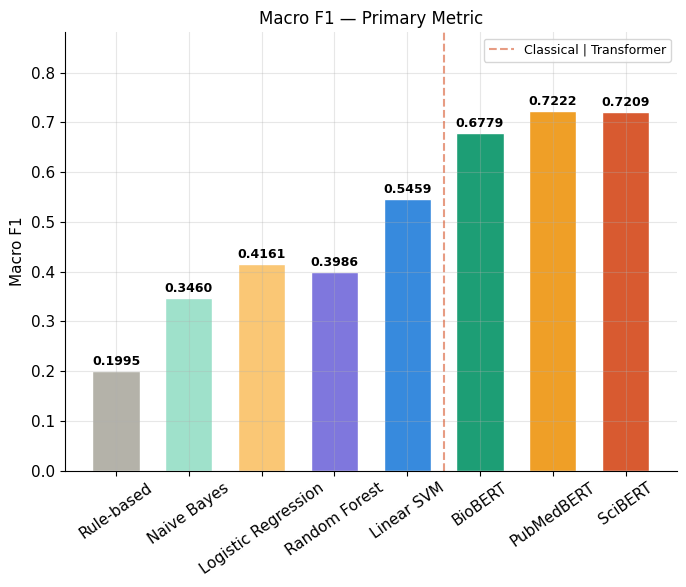

In [5]:
# Compute metrics for plotting
colours = [MODEL_COLOURS.get(m, '#888780') for m in available]
macro_f1s = [f1_score(y_test, all_preds[m], average='macro', zero_division=0) for m in available]
mcc_vals  = [matthews_corrcoef(y_test, all_preds[m]) for m in available]
bal_accs = [balanced_accuracy_score(y_test, all_preds[m]) for m in available]

# Plot Macro F1 scores
plt.figure(figsize=(7, 6))

bars = plt.bar(
    available,
    macro_f1s,
    color=colours,
    edgecolor='white',
    width=0.65
)

# Annotate bars
for bar, val in zip(bars, macro_f1s):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.006,
        f'{val:.4f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Separate classical and transformer models
classical_in_avail = [m for m in available if model_type(m) == 'Classical ML']
trans_in_avail = [m for m in available if model_type(m) == 'Transformer']

if classical_in_avail and trans_in_avail:
    boundary = (
        available.index(classical_in_avail[-1]) +
        available.index(trans_in_avail[0])
    ) / 2
    
    plt.axvline(
        boundary,
        color='#D85A30',
        linestyle='--',
        alpha=0.6,
        label='Classical | Transformer'
    )
    
    plt.legend(fontsize=9)

# Plot formatting
plt.title('Macro F1 — Primary Metric', fontsize=12)
plt.ylabel('Macro F1')
plt.xticks(rotation=35)
plt.ylim(0, max(macro_f1s) * 1.22)

plt.tight_layout()
plt.savefig(str(FIG_DIR / 'macro_f1.png'), dpi=150, bbox_inches='tight')
plt.show()

## Matthews Correlation Coefficient (MCC) Comparison

This plot compares models using the Matthews Correlation Coefficient, a robust metric that accounts for all elements of the confusion matrix. It is particularly useful for imbalanced datasets as it provides a balanced evaluation of prediction quality.

Higher MCC values indicate better overall classification performance.

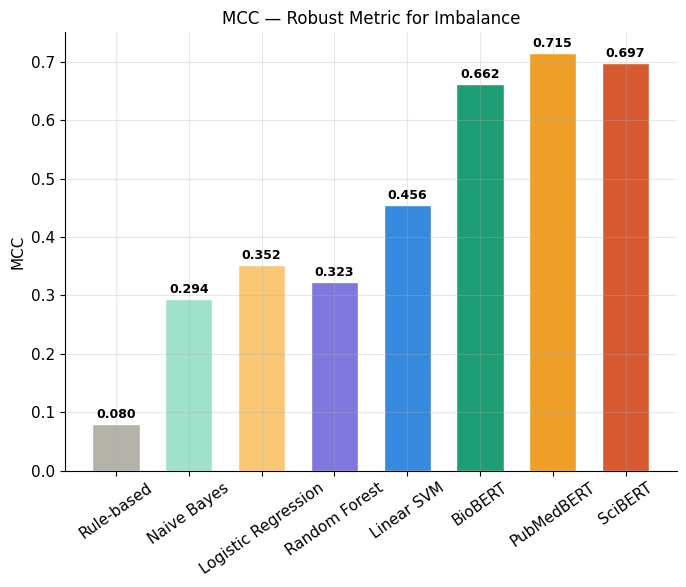

In [6]:
# Plot MCC scores
plt.figure(figsize=(7, 6))

bars = plt.bar(
    available,
    mcc_vals,
    color=colours,
    edgecolor='white',
    width=0.65
)

# Annotate bars
for bar, val in zip(bars, mcc_vals):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Plot formatting
plt.title('MCC — Robust Metric for Imbalance', fontsize=12)
plt.ylabel('MCC')
plt.xticks(rotation=35)

plt.tight_layout()
plt.savefig(str(FIG_DIR / 'multi_metric_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## Multi-Metric Comparison

This visualisation compares models across multiple evaluation metrics, including Macro F1, Balanced Accuracy, and MCC. Presenting these metrics together provides a more comprehensive view of model performance.

The grouped bar chart highlights differences in how models perform under different evaluation criteria, offering deeper insight beyond a single metric.

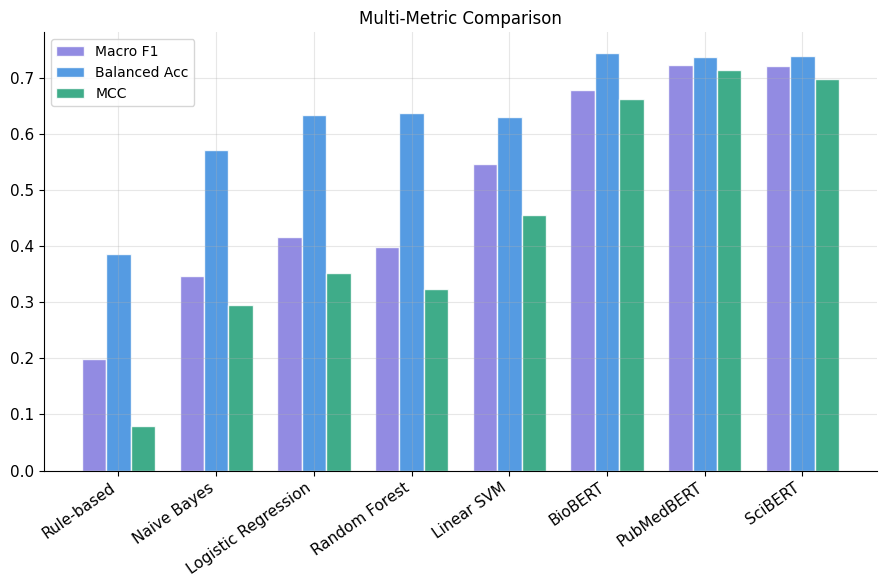

In [7]:
# Plot multiple evaluation metrics
plt.figure(figsize=(9, 6))

x = np.arange(len(available))
w = 0.25

# Plot grouped bars
plt.bar(
    x - w,
    macro_f1s,
    w,
    label='Macro F1',
    color='#7F77DD',
    alpha=0.85,
    edgecolor='white'
)

plt.bar(
    x,
    bal_accs,
    w,
    label='Balanced Acc',
    color='#378ADD',
    alpha=0.85,
    edgecolor='white'
)

plt.bar(
    x + w,
    mcc_vals,
    w,
    label='MCC',
    color='#1D9E75',
    alpha=0.85,
    edgecolor='white'
)

# Plot formatting
plt.xticks(x, available, rotation=35, ha='right')
plt.title('Multi-Metric Comparison', fontsize=12)
plt.legend(fontsize=10)

plt.tight_layout()
plt.savefig(str(FIG_DIR / 'multi_metric.png'), dpi=150, bbox_inches='tight')
plt.show()

## Per-Class F1 Score Heatmap

This heatmap visualises model performance at the class level using F1 scores. Each row represents a model, while each column corresponds to a specific interaction type.

The heatmap enables identification of strengths and weaknesses across classes, highlighting which interaction types are more challenging and where certain models perform better.

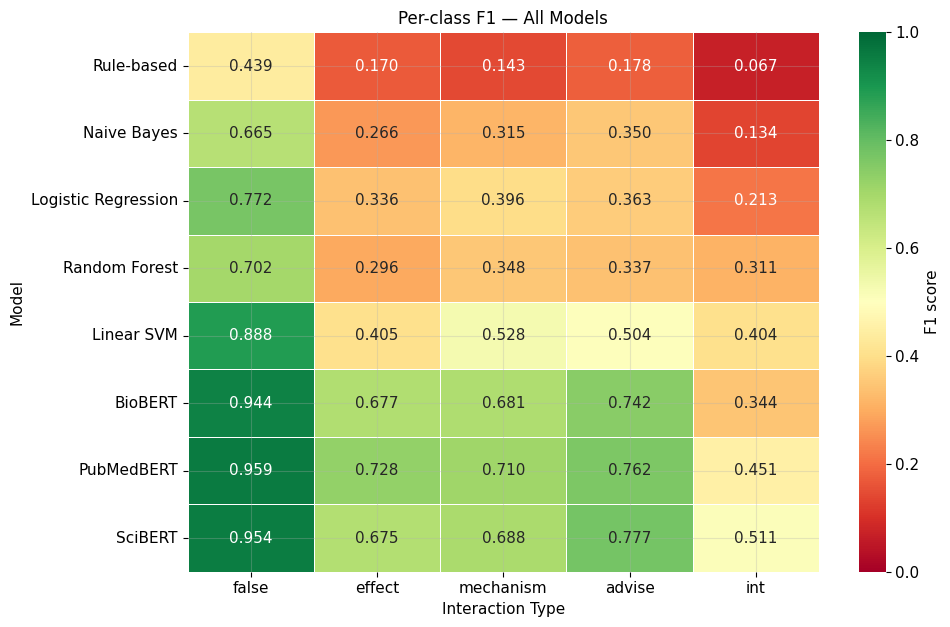

In [8]:
# Compute per-class F1 scores for each model
per_class = {}

for name in available:
    rep = classification_report(
        y_test,
        all_preds[name],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )
    
    per_class[name] = [
        rep[lbl]['f1-score'] for lbl in LABEL_ORDER
    ]

# Create DataFrame for heatmap
hm_df = (
    pd.DataFrame(per_class, index=LABEL_ORDER)
    .T
    .reindex(available)
)

# Plot heatmap
plt.figure(figsize=(10, max(4, len(available) * 0.8)))

sns.heatmap(
    hm_df,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    linewidths=0.5,
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'F1 score'}
)

# Plot formatting
plt.title('Per-class F1 — All Models', fontsize=12)
plt.xlabel('Interaction Type')
plt.ylabel('Model')

plt.tight_layout()
plt.savefig(str(FIG_DIR / 'perclass_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## Per-Class Performance Difference (F1)

This plot compares the best transformer model against the best classical model at the class level using the difference in F1 scores.

Positive values indicate classes where the transformer outperforms the classical model, while negative values highlight cases where the classical model performs better. This helps identify where deep models provide meaningful gains.

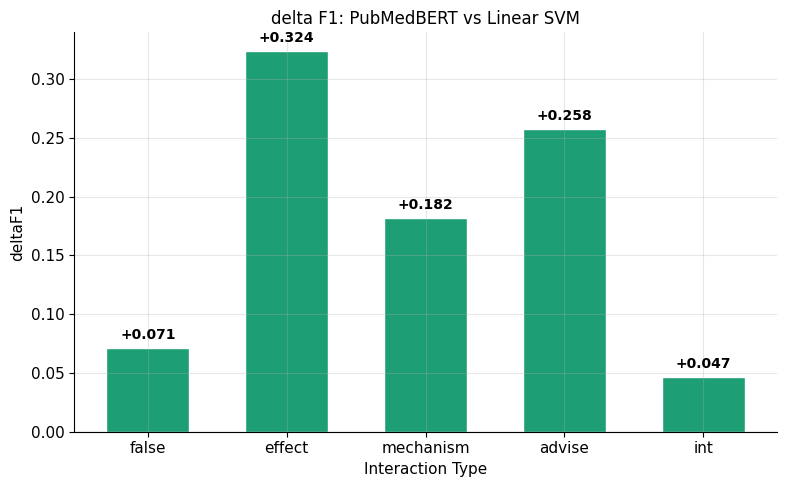

In [9]:
# Compare per-class F1 differences between best transformer and classical model
if best_trans and best_clf and best_trans in hm_df.index and best_clf in hm_df.index:

    # Compute difference
    delta = hm_df.loc[best_trans] - hm_df.loc[best_clf]

    # Assign colors based on improvement or decline
    bar_cols = ['#1D9E75' if v >= 0 else '#D85A30' for v in delta]

    plt.figure(figsize=(8, 5))

    # Plot bar chart
    plt.bar(
        LABEL_ORDER,
        delta.values,
        color=bar_cols,
        edgecolor='white',
        width=0.6
    )

    # Reference line at zero
    plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)

    # Annotate values
    for i, val in enumerate(delta.values):
        plt.text(
            i,
            val + (0.005 if val >= 0 else -0.015),
            f'{val:+.3f}',
            ha='center',
            va='bottom' if val >= 0 else 'top',
            fontsize=10,
            fontweight='bold'
        )

    # Plot formatting
    plt.title(f'delta F1: {best_trans} vs {best_clf}', fontsize=12)
    plt.xlabel('Interaction Type')
    plt.ylabel('deltaF1')

    plt.tight_layout()
    plt.savefig(str(FIG_DIR / 'perclass_delta.png'), dpi=150, bbox_inches='tight')
    plt.show()

else:
    print('Run Phase 6 notebooks first to compute transformer results.')

## Transformer Model Comparison (Macro F1 vs MCC)

This plot compares transformer-based models using both Macro F1 and MCC. While Macro F1 captures balanced class-wise performance, MCC provides a more robust evaluation in the presence of class imbalance.

The dual-metric representation helps assess whether performance gains are consistent across different evaluation perspectives.

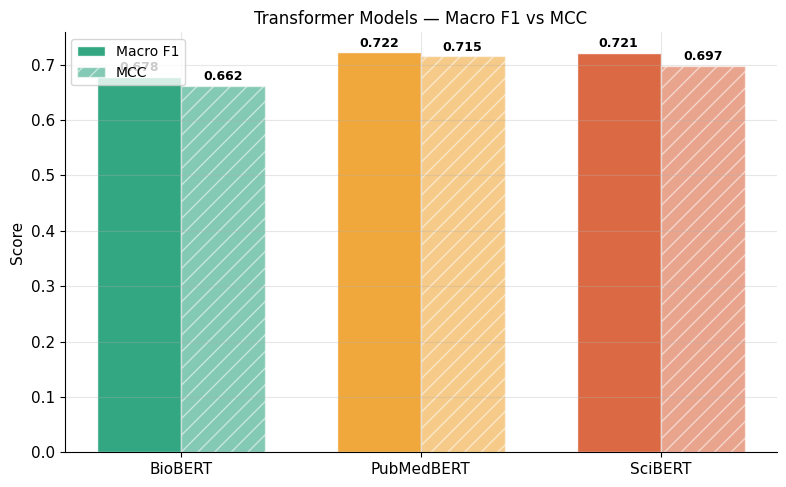

In [10]:
# Compare transformer models using Macro F1 and MCC
if not trans_available:
    print('No transformer predictions available. run Phase 6a/6b/6c first.')
else:
    plt.figure(figsize=(8, 5))

    x = np.arange(len(trans_available))
    w = 0.35

    # Compute metrics
    t_f1s = [
        f1_score(y_test, all_preds[m], average='macro', zero_division=0)
        for m in trans_available
    ]
    t_mcc = [
        matthews_corrcoef(y_test, all_preds[m])
        for m in trans_available
    ]

    # Colors
    t_cols = [MODEL_COLOURS.get(m, '#888') for m in trans_available]

    # Plot bars
    b1 = plt.bar(
        x - w/2,
        t_f1s,
        w,
        label='Macro F1',
        color=t_cols,
        alpha=0.9,
        edgecolor='white'
    )

    b2 = plt.bar(
        x + w/2,
        t_mcc,
        w,
        label='MCC',
        color=t_cols,
        alpha=0.55,
        edgecolor='white',
        hatch='//'
    )

    # Annotate values
    for bar, val in list(zip(b1, t_f1s)) + list(zip(b2, t_mcc)):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    # Plot formatting
    plt.xticks(x, trans_available)
    plt.title('Transformer Models — Macro F1 vs MCC', fontsize=12)
    plt.ylabel('Score')
    plt.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig(str(FIG_DIR / 'transformer_metrics.png'), dpi=150, bbox_inches='tight')
    plt.show()

## Per-Class F1 Comparison — Transformer Models

This plot provides a detailed comparison of transformer models at the class level using F1 scores. Each group of bars corresponds to an interaction type, with individual bars representing different transformer models.

This analysis highlights how each transformer performs across specific classes, revealing class-wise strengths and weaknesses that may not be visible in aggregate metrics.

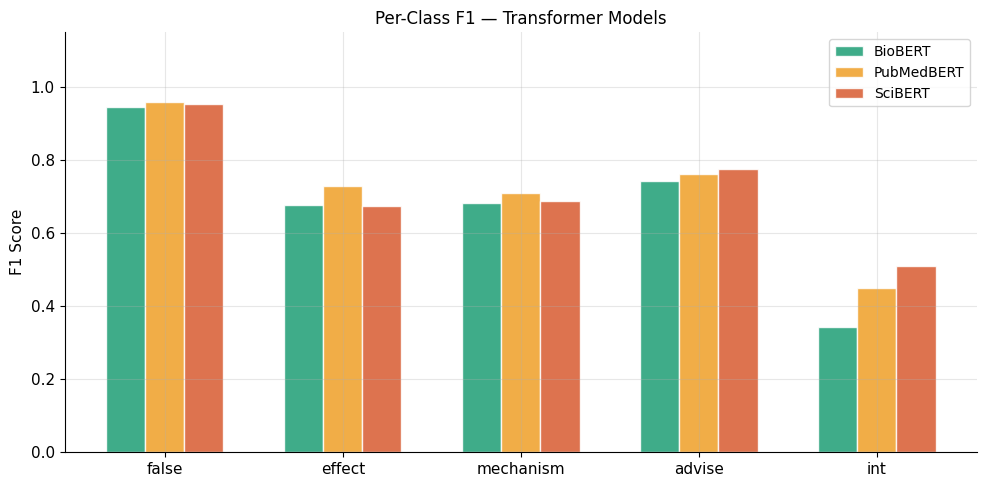

In [11]:
# Per-class F1 comparison for transformer models
if not trans_available:
    print('No transformer predictions available — run Phase 6a/6b/6c first.')
else:
    plt.figure(figsize=(10, 5))

    n_trans = len(trans_available)
    x2 = np.arange(len(LABEL_ORDER))
    bar_width = 0.22

    # Plot per-class F1 for each transformer
    for j, (tname, tcol) in enumerate([
        (m, MODEL_COLOURS.get(m, '#888')) for m in trans_available
    ]):
        
        rep = classification_report(
            y_test,
            all_preds[tname],
            target_names=CLASS_NAMES,
            output_dict=True,
            zero_division=0
        )

        f1s = [rep[lbl]['f1-score'] for lbl in LABEL_ORDER]

        # Offset bars for grouped visualization
        offset = (j - n_trans/2 + 0.5) * bar_width

        plt.bar(
            x2 + offset,
            f1s,
            bar_width,
            label=tname,
            color=tcol,
            alpha=0.85,
            edgecolor='white'
        )

    # Plot formatting
    plt.xticks(x2, LABEL_ORDER)
    plt.title('Per-Class F1 — Transformer Models', fontsize=12)
    plt.ylabel('F1 Score')
    plt.ylim(0, 1.15)
    plt.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig(str(FIG_DIR / 'transformer_per_class.png'), dpi=150, bbox_inches='tight')
    plt.show()

## Confusion Matrix — Rule-Based Model

This heatmap presents the normalised confusion matrix for the rule-based classifier. Each row is normalised to highlight the distribution of predictions for each true class.

This representation helps assess how well the rule-based approach captures different interaction types and where misclassifications are concentrated.

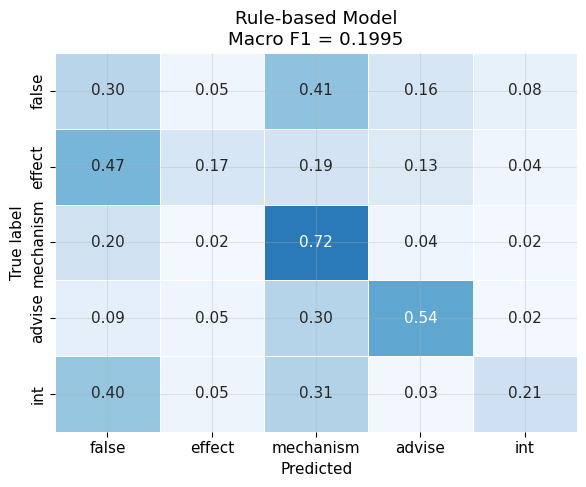

In [12]:
# Confusion matrix for rule-based model
if 'Rule-based' in all_preds:
    model_name = 'Rule-based'
    preds = all_preds[model_name]

    # Compute confusion matrix
    cm = confusion_matrix(y_test, preds)

    # Reorder matrix to match label order
    idx = [CLASS_NAMES.index(l) for l in LABEL_ORDER]
    cm_ord = cm[np.ix_(idx, idx)]

    # Row-wise normalisation
    rsums = cm_ord.sum(axis=1, keepdims=True)
    rsums[rsums == 0] = 1
    cm_norm = cm_ord / rsums

    # Compute Macro F1
    f1 = f1_score(y_test, preds, average='macro', zero_division=0)

    # Plot heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=LABEL_ORDER,
        yticklabels=LABEL_ORDER,
        vmin=0,
        vmax=1,
        cbar=False,
        linewidths=0.5
    )

    # Plot formatting
    plt.title(f'Rule-based Model\nMacro F1 = {f1:.4f}')
    plt.xlabel('Predicted')
    plt.ylabel('True label')

    plt.tight_layout()
    plt.savefig(str(FIG_DIR / 'confusion_matrix_rule_based.png'), dpi=150, bbox_inches='tight')
    plt.show()

else:
    print('Rule-based predictions not available.')

## Confusion Matrix — Classical Model

This heatmap visualises the performance of the best available classical machine learning model using a normalised confusion matrix.

Each row is normalised to show how predictions are distributed for each true class, enabling clear identification of systematic misclassifications and class-specific performance patterns.

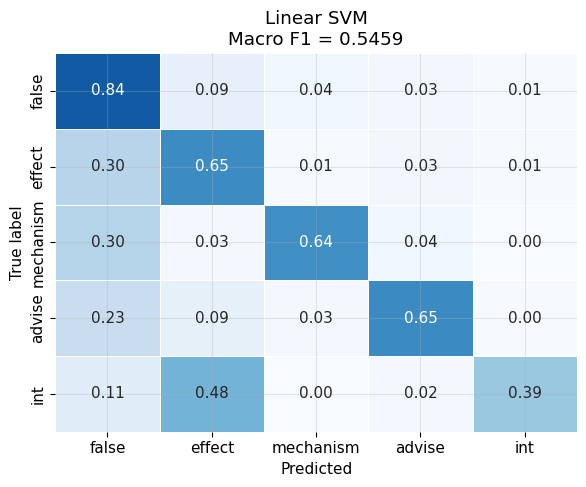

In [13]:
# Confusion matrix for best classical model
classical_models = ['Naive Bayes', 'Logistic Regression', 'Random Forest', 'Linear SVM']
available_classical = [m for m in classical_models if m in all_preds]

if available_classical:
    # Select best classical model (assumed ordered by performance)
    model_name = best_clf
    preds = all_preds[model_name]

    # Compute confusion matrix
    cm = confusion_matrix(y_test, preds)

    # Reorder according to label order
    idx = [CLASS_NAMES.index(l) for l in LABEL_ORDER]
    cm_ord = cm[np.ix_(idx, idx)]

    # Row-wise normalisation
    rsums = cm_ord.sum(axis=1, keepdims=True)
    rsums[rsums == 0] = 1
    cm_norm = cm_ord / rsums

    # Compute Macro F1
    f1 = f1_score(y_test, preds, average='macro', zero_division=0)

    # Plot heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=LABEL_ORDER,
        yticklabels=LABEL_ORDER,
        vmin=0,
        vmax=1,
        cbar=False,
        linewidths=0.5
    )

    # Plot formatting
    plt.title(f'{model_name}\nMacro F1 = {f1:.4f}')
    plt.xlabel('Predicted')
    plt.ylabel('True label')

    plt.tight_layout()
    plt.savefig(str(FIG_DIR / 'confusion_matrix_classical.png'), dpi=150, bbox_inches='tight')
    plt.show()

else:
    print('No classical model predictions available.')

## Confusion Matrix — Transformer Model

This heatmap illustrates the performance of the best available transformer model using a normalised confusion matrix.

Row-wise normalisation highlights how each true class is distributed across predicted classes, providing insight into model strengths and common misclassification patterns across interaction types.

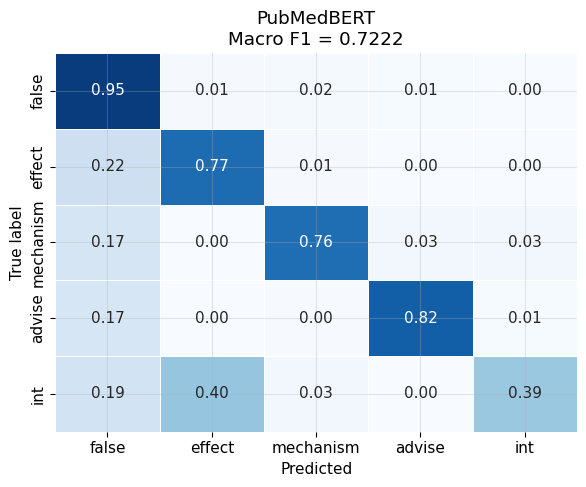

In [14]:
# Confusion matrix for best transformer model
transformers = ['BioBERT', 'PubMedBERT', 'SciBERT']
available_trans = [m for m in transformers if m in all_preds]

if available_trans:
    # Select best transformer model (assumed ordered by performance)
    model_name = best_trans
    preds = all_preds[model_name]

    # Compute confusion matrix
    cm = confusion_matrix(y_test, preds)

    # Reorder according to label order
    idx = [CLASS_NAMES.index(l) for l in LABEL_ORDER]
    cm_ord = cm[np.ix_(idx, idx)]

    # Row-wise normalisation
    rsums = cm_ord.sum(axis=1, keepdims=True)
    rsums[rsums == 0] = 1
    cm_norm = cm_ord / rsums

    # Compute Macro F1
    f1 = f1_score(y_test, preds, average='macro', zero_division=0)

    # Plot heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=LABEL_ORDER,
        yticklabels=LABEL_ORDER,
        vmin=0,
        vmax=1,
        cbar=False,
        linewidths=0.5
    )

    # Plot formatting
    plt.title(f'{model_name}\nMacro F1 = {f1:.4f}')
    plt.xlabel('Predicted')
    plt.ylabel('True label')

    plt.tight_layout()
    plt.savefig(str(FIG_DIR / 'confusion_matrix_transformer.png'), dpi=150, bbox_inches='tight')
    plt.show()

else:
    print('No transformer model predictions available.')

## Error Analysis — Best Model

This section analyses prediction errors of the best-performing model. It examines overall accuracy, common misclassification patterns, and critical failure cases such as missed interactions.

Additionally, it identifies *persistent errors*—instances that are misclassified by all models—highlighting inherently challenging samples in the dataset.

In [15]:
# Error analysis for best model
if best_model not in all_preds:
    print(f'Best model ({best_model}) predictions not available.')
else:
    best_col = best_model.lower().replace(' ', '_').replace('-', '_') + '_pred'
    interaction_classes = [l for l in LABEL_ORDER if l != 'false']

    # Map predictions to labels
    test_df['true_label'] = test_df['interaction_type']
    test_df[best_col] = [ID2LABEL[p] for p in all_preds[best_model]]

    # Split correct vs incorrect predictions
    errors  = test_df[test_df[best_col] != test_df['true_label']]
    correct = test_df[test_df[best_col] == test_df['true_label']]

    print(f'Best model : {best_model}')
    print(f'Correct : {len(correct):,} / {len(test_df):,} ({len(correct)/len(test_df)*100:.1f}%)')
    print(f'Errors : {len(errors):,}  ({len(errors)/len(test_df)*100:.1f}%)')

    # Most frequent error patterns
    print('\nTop error patterns (true → predicted):')
    errs = (
        errors.groupby(['true_label', best_col])
        .size()
        .reset_index(name='count')
    )
    print(
        errs.sort_values('count', ascending=False)
            .head(12)
            .to_string(index=False)
    )

    # Critical errors: missed interactions
    dangerous = errors[
        (errors['true_label'].isin(interaction_classes)) &
        (errors[best_col] == 'false')
    ]

    print(f'\nDangerous misses (interaction predicted as false): {len(dangerous):,}')
    print(f'= {len(dangerous)/len(errors)*100:.1f}% of all errors')
    print()

    # Persistent errors across all models
    mask_all_wrong = pd.Series(True, index=test_df.index)

    for m in available:
        col = m.lower().replace(' ', '_').replace('-', '_') + '_pred'
        test_df[col] = [ID2LABEL[p] for p in all_preds[m]]
        mask_all_wrong &= (test_df[col] != test_df['true_label'])

    persistent = test_df[mask_all_wrong]

    print(f'Persistent errors (all {len(available)} models wrong): {len(persistent):,} ({len(persistent)/len(test_df)*100:.1f}%)')
    print('True label distribution of persistent errors:')
    print(persistent['true_label'].value_counts().to_string())

Best model : PubMedBERT
Correct : 6,130 / 6,657 (92.1%)
Errors : 527  (7.9%)

Top error patterns (true → predicted):
true_label pubmedbert_pred  count
     false       mechanism    107
     false          effect     83
    effect           false     78
     false          advise     62
 mechanism           false     52
       int          effect     38
    advise           false     37
     false             int     20
       int           false     18
 mechanism          advise     10
 mechanism             int      9
    effect       mechanism      5

Dangerous misses (interaction predicted as false): 185
= 35.1% of all errors

Persistent errors (all 8 models wrong): 131 (2.0%)
True label distribution of persistent errors:
true_label
false        66
int          41
advise       14
effect        8
mechanism     2


## Summary

The comparative evaluation demonstrates a consistent performance hierarchy across modelling paradigms: **Rule-based → Classical Machine Learning → Transformer-based models**. Each successive tier shows measurable improvement in predictive capability, particularly in handling nuanced and context-dependent interaction patterns.

Statistical validation using McNemar’s test confirms that these improvements are not incidental, but **statistically significant**, reinforcing the reliability of the observed performance gains.

To support downstream analysis, the generated `best_model_info.json` enables